In [1]:
!pip install opencv-python numpy matplotlib


✅ Image loaded successfully

--- Compression Results ---
Compression Ratio: 0.68
Storage Savings (%): -47.71


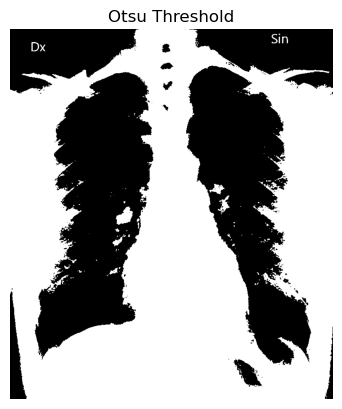

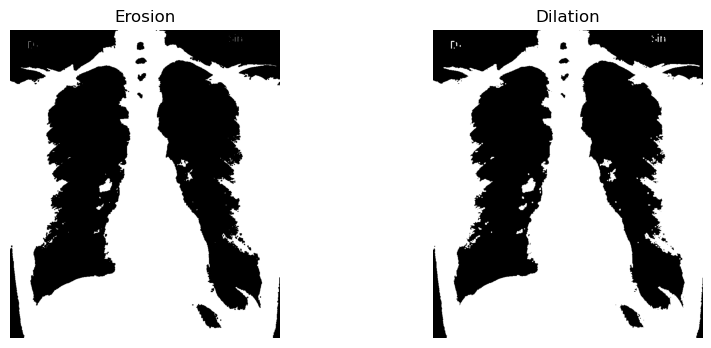

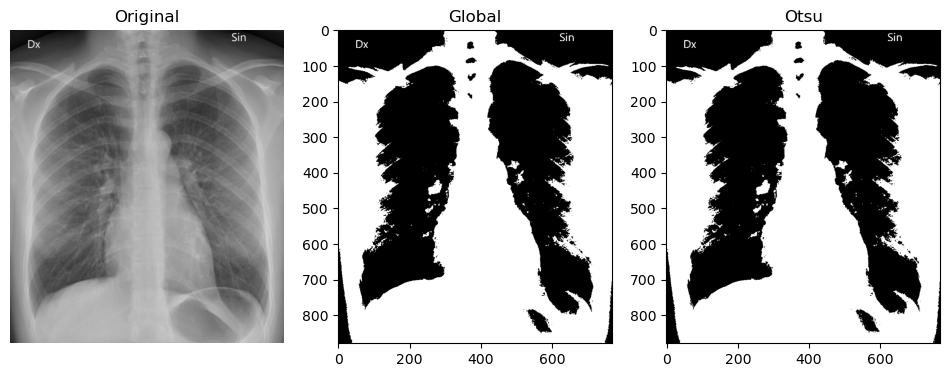


✅ All outputs saved in 'outputs' folder


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
image_path = r"D:\Downloads\Medical image compression and segmentation\Image\xray.png"

image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if image is None:
    print("❌ Image not loaded — check file name/path")
else:
    print("✅ Image loaded successfully")
    plt.imshow(image, cmap='gray')
    plt.title("Original Image")
    plt.axis('off')

def run_length_encoding(image):
    flat = image.flatten()
    rle = []
    prev = flat[0]
    count = 1

    for pixel in flat[1:]:
        if pixel == prev:
            count += 1
        else:
            rle.append((prev, count))
            prev = pixel
            count = 1

    rle.append((prev, count))
    return rle


def compression_stats(image, rle):
    original_size = image.size
    compressed_size = len(rle) * 2

    ratio = original_size / compressed_size
    savings = (1 - compressed_size / original_size) * 100

    return ratio, savings


rle = run_length_encoding(image)
ratio, savings = compression_stats(image, rle)

print("\n--- Compression Results ---")
print("Compression Ratio:", round(ratio, 2))
print("Storage Savings (%):", round(savings, 2))

_, global_seg = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY)

plt.imshow(global_seg, cmap='gray')
plt.title("Global Threshold")
plt.axis('off')

_, otsu_seg = cv2.threshold(image, 0, 255,
                           cv2.THRESH_BINARY + cv2.THRESH_OTSU)

plt.imshow(otsu_seg, cmap='gray')
plt.title("Otsu Threshold")
plt.axis('off')

kernel = np.ones((3,3), np.uint8)

erosion = cv2.erode(otsu_seg, kernel, iterations=1)
dilation = cv2.dilate(erosion, kernel, iterations=1)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(erosion, cmap='gray')
plt.title("Erosion")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(dilation, cmap='gray')
plt.title("Dilation")
plt.axis('off')

plt.figure(figsize=(12,5))

plt.subplot(1,3,1)
plt.imshow(image, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(global_seg, cmap='gray')
plt.title("Global")

plt.subplot(1,3,3)
plt.imshow(otsu_seg, cmap='gray')
plt.title("Otsu")

plt.show()

output_dir = "outputs"
os.makedirs(output_dir, exist_ok=True)

cv2.imwrite(f"{output_dir}/original.png", image)
cv2.imwrite(f"{output_dir}/global.png", global_seg)
cv2.imwrite(f"{output_dir}/otsu.png", otsu_seg)
cv2.imwrite(f"{output_dir}/erosion.png", erosion)
cv2.imwrite(f"{output_dir}/dilation.png", dilation)

# Save partial RLE
with open(f"{output_dir}/rle.txt", "w") as f:
    f.write(str(rle[:1000]))

print("\n✅ All outputs saved in 'outputs' folder")

## Analysis

- Global thresholding provides basic segmentation but is not adaptive.
- Otsu’s method automatically selects the optimal threshold → better segmentation.
- Morphological operations remove noise and refine boundaries.
- This helps in identifying lungs and important structures in X-ray images.